In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
import math
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Question 1 :

In [3]:
# !pip install torch torchvision

In [4]:
LMDA=0.07

In [5]:
def initialize_parameters(layer_dims):
  to_return={}
  torch.manual_seed(358)
  for i in range(1,len(layer_dims)):
    w_vec=torch.normal(mean=0, std=np.sqrt(2/layer_dims[i]), size=(layer_dims[i], layer_dims[i-1]))
    b_vec=torch.zeros(layer_dims[i],1)
    to_return[i]=[w_vec,b_vec]
  return to_return

In [6]:
def linear_forward(A, W, b):
    Z = torch.mm(W,A)+ b
    linear_cache = {'A': A, 'W': W, 'b': b}
    return Z, linear_cache

In [7]:
def softmax(Z):
    exp_Z = torch.exp(Z)
    A = exp_Z / torch.sum(exp_Z,dim=0)
    return A, Z

In [8]:
def relu(Z):
  return np.maximum(0, Z),Z

In [9]:
def linear_activation_forward(A_prev, W, B, activation):
  Z,linear_cache=linear_forward(A_prev, W, B)
  if activation=='softmax':
    A,activation_cache=softmax(Z)
  else:
    A,activation_cache=relu(Z)
  return A,{'linear_cache':linear_cache,'activation_cache':activation_cache}

In [10]:
def L_model_forward(X, parameters, use_batchnorm):
    X = torch.tensor(X,dtype=torch.float32)
    n_layers = len(parameters)
    caches = []

    # Propagate the first layer
    Ai, cache = linear_activation_forward(X, parameters[1][0], parameters[1][1], "relu")
    caches.append(cache)

    # Propagate all linear layers
    for i in range(2, n_layers):
        W, B = parameters[i]

        if not use_batchnorm:
            Ai, cache = linear_activation_forward(Ai, W, B, 'relu')
        else:
            Ai = apply_batchnorm(Ai)
            Ai, cache = linear_activation_forward(Ai, W, B, 'relu')
        caches.append(cache)

    # Propagate the softmax layer
    if not use_batchnorm:
        AL, cache = linear_activation_forward(Ai, parameters[n_layers][0], parameters[n_layers][1], 'softmax')
    else:
        Ai = apply_batchnorm(Ai)
        AL, cache = linear_activation_forward(Ai, parameters[n_layers][0], parameters[n_layers][1], 'softmax')

    caches.append(cache)

    return AL, caches

In [11]:
def compute_cost(AL,Y,l2_norm,paramters={}):
    w_2=0
    if l2_norm:
      for i in range(1,len(paramters)+1):
        w_2+=torch.sum(paramters[i][0]**2).item()
    cost = (np.log(AL)*Y).T
    cost = -(cost.sum().item()) / AL.shape[1]
    return cost+(w_2*LMDA)/(2*AL.shape[1])
#LMDA is global prameter i defined in the begging of the notebook

In [12]:
def apply_batchnorm(A):
    epsilon = 1e-8
    mean = torch.mean(A, dim=1, keepdim=True)
    variance = torch.var(A, dim=1, unbiased=False, keepdim=True)
    return (A - mean) / torch.sqrt(variance + epsilon)

Question 2 :

In [13]:
def linear_backward(dZ, cache):
    A_prev= cache['A']
    W= cache['W']
    dW = torch.mm(dZ, A_prev.t())
    db = dZ.mean(axis=1)
    dA_prev = torch.mm(W.t(), dZ)
    return dA_prev, dW, db

In [14]:
def linear_activation_backward(dA, cache, activation):
    linear_cache = cache['linear_cache']
    activation_cache = cache['activation_cache']

    if activation == "relu":
        dZ = relu_backward(dA, activation_cache)
    elif activation == "softmax":
        pass#since we  calcualte this type of  derivative only once in the last layer of DNN i decided to preform it only in the L_model_backward

    dA_prev, dW, db = linear_backward(dZ, linear_cache)
    return dA_prev, dW, db

In [15]:
def relu_backward(dA, activation_cache):
  return dA * (activation_cache > 0).float()

In [16]:
def softmax_backward(dA, activation_cache):
  return

In [17]:
def L_model_backward(AL,Y,caches):
        grads = {}
        L = len(caches)-1
        cach_dict= caches[L]
        dA_prev, dW, db = linear_backward(AL-Y,cach_dict['linear_cache'])#AL-Y is the derivative of softmax
        grads[f'dA{L+1}'] = dA_prev/L
        grads[f'dW{L+1}'] = dW/L
        grads[f'db{L+1}'] = db/L

        while L>0:
            current_cache = caches[L-1]
            dA_prev, dW, db = linear_activation_backward(grads[f'dA{L+1}'], current_cache, activation="relu")
            grads[f'dA{L}'] = dA_prev/L
            grads[f'dW{L}'] = dW/L
            grads[f'db{L}'] = db/L
            L-=1
        return grads

In [18]:
def Update_parameters(parameters, grads, learning_rate,l2_norm):
  for i,par in parameters.items():
    W=par[0]
    b=par[1]
    dW=grads[f"dW{i}"]
    db=grads[f"db{i}"]

    if l2_norm:
      W=W-learning_rate*(dW+LMDA*W)
    else:
      W=W-learning_rate*dW

    b-=learning_rate*db.view(-1,1)
    parameters[i]=(W,b)

  return parameters

In [19]:
def L_layer_model(X, Y, layers_dims, learning_rate, num_iterations, batch_size,batch_norm,l2_norm):
        costs = [-1]
        costs_valid=[-1]
        params = initialize_parameters(layers_dims)

        X, X_val, Y, Y_val = train_test_split(X.T,Y.T, test_size=0.3, random_state=42)
        X, X_val, Y, Y_val=X.T, X_val.T, Y.T, Y_val.T

        train_step=0
        train_idx=0
        for iter in range(0, num_iterations):
          for i in range(0, X.shape[1], batch_size):
            curr_batch_X = X[:,i:i+batch_size]
            curr_batch_Y = Y[:,i:i+batch_size]
            #activate the L layer forward on the train
            AL, caches = L_model_forward(curr_batch_X, params,batch_norm)
            cost_train = compute_cost(AL, curr_batch_Y,l2_norm)
            #evaluate the L layer forwrad on the validtaion
            AL_valid, caches_valid = L_model_forward(X_val, params,batch_norm)
            #calcualte the grads on the train
            cost_valid=compute_cost(AL_valid, Y_val,l2_norm)
            grads = L_model_backward(AL, curr_batch_Y, caches)
            #with the help of the grades calcualte the params on the train
            params = Update_parameters(params, grads, learning_rate,l2_norm)

            if train_step>=100:
                train_step=0
                costs.append(cost_train)#the train cost in each 100 training steps.
                costs_valid.append(cost_valid)#the validation cost  in each 100 training steps.
                print(f"training step:{train_idx}, validation cost:{cost_valid}, train cost:{cost_train}, validation accuracy:{Predict(X_val,Y_val,params,batch_norm)}")
                if abs(cost_valid-costs_valid[-2])<1e-8:
                  return params, costs[1:],costs_valid[:1]
            train_idx+=1
            train_step+=1
            #calculate the grads
        print('final results:')
        print(f"training step:{train_idx}, current_cost:{cost_valid}, train cost:{cost_train},train accuracy:{Predict(X,Y,params,batch_norm)}")
        return params, costs[1:],costs_valid[1:]

In [20]:
torch.finfo(torch.float64).eps

2.220446049250313e-16

In [21]:
def Predict(X, Y, parameters,batch_norm):
    AL,caches_for_1sample_layers=L_model_forward(X,parameters,batch_norm)
    the_index_of_max_probs=np.argmax(AL,axis=0)
    the_index_of_true_label=np.argmax(Y,axis=0)
    return sum(the_index_of_max_probs==the_index_of_true_label)/X.shape[1]

# In this section We trined the model and collected some insights

## **It also included the functions we used to create the report results **

In [22]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from sklearn.model_selection import train_test_split

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Preprocess the data and flatten the images
train_images, test_images = train_images / 255.0, test_images / 255.0
train_images = train_images.reshape((train_images.shape[0], 28 * 28))
test_images = test_images.reshape((test_images.shape[0], 28 * 28))

# One-Hot Encode Labels
train_labels = tf.keras.utils.to_categorical(train_labels, num_classes=10)
test_labels = tf.keras.utils.to_categorical(test_labels, num_classes=10)


train_images_tensor = torch.tensor(train_images.T)
train_labels_tensor = torch.tensor(train_labels.T)
test_images_tensor = torch.tensor(test_images.T, dtype=torch.float64)
test_labels_tensor = torch.tensor(test_labels.T, dtype=torch.float64)


11490434/11490434 [==============================] - 0s 0us/step


In [23]:
# import time
# current_time = time.time()
# input_size = 28*28
# layers_dims = [input_size, 20, 7, 5, 10]

# with tf.device('/GPU:0'):
#     L_layer_model=L_layer_model
#     train_images_tensor=train_images_tensor
#     train_labels_tensor=train_labels_tensor

# params, costs,cost_valid = L_layer_model(train_images_tensor,train_labels_tensor, layers_dims, learning_rate=0.009, num_iterations=15, batch_size=32,batch_norm=False,l2_norm=False)
# end=time.time()
# print(f"test accuracy:{Predict(test_images_tensor,test_labels_tensor,params,True)}")
# print('elapsed time',end-current_time)

In [24]:
# import matplotlib.pyplot as plt


# plt.plot(cost_valid, label='Validation Costs')
# plt.plot(costs, label='Training Costs')

# plt.xlabel('Epochs')
# plt.ylabel('Cost')
# plt.title('Training and Validation Costs')

# plt.legend()

# plt.show()

In [25]:
# import time
# current_time = time.time()
# input_size = 28*28
# layers_dims = [input_size, 20, 7, 5, 10]

# with tf.device('/GPU:0'):
#     L_layer_model=L_layer_model
#     train_images_tensor=train_images_tensor
#     train_labels_tensor=train_labels_tensor

# params, costs,cost_valid = L_layer_model(train_images_tensor,train_labels_tensor, layers_dims, learning_rate=0.009, num_iterations=12, batch_size=32,batch_norm=True,l2_norm=False)
# end=time.time()
# print(f"test accuracy:{Predict(test_images_tensor,test_labels_tensor,params,True)}")
# print('elapsed time',end-current_time)

In [26]:
# import matplotlib.pyplot as plt
# plt.plot(cost_valid, label='Validation Costs')
# plt.plot(costs, label='Training Costs')
# plt.xlabel('Epochs')
# # plt.ylabel('Cost')
# # plt.title('Training and Validation Costs using batchNorm')

# # plt.legend()
# plt.show()

In [27]:
# import matplotlib.pyplot as plt
# all_weights=[]
# for key,value in params.items():
#   for w in value[0].flatten():
#     all_weights.append(w)

# plt.hist(all_weights, bins='auto', color='blue', edgecolor='black')
# plt.xlabel('weights')
# plt.ylabel('Frequency')
# plt.title('Distribution of weights using batch norm')
# plt.show()

In [28]:
import time
current_time = time.time()
input_size = 28*28
layers_dims = [input_size, 20, 7, 5, 10]

with tf.device('/GPU:0'):
    L_layer_model=L_layer_model
    train_images_tensor=train_images_tensor
    train_labels_tensor=train_labels_tensor

params, costs,cost_valid = L_layer_model(train_images_tensor,train_labels_tensor, layers_dims, learning_rate=0.009, num_iterations=15, batch_size=32,batch_norm=True,l2_norm=True)
end=time.time()
print(f"test accuracy:{Predict(test_images_tensor,test_labels_tensor,params,True)}")
print('elapsed time',end-current_time)

<ipython-input-10-95be2dd2be76>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X,dtype=torch.float32)


training step:100, validation cost:1.9665052083333334, train cost:1.8523471355438232, validation accuracy:0.3367222249507904
training step:200, validation cost:1.7853519965277778, train cost:1.7338440418243408, validation accuracy:0.391222208738327
training step:300, validation cost:1.6187853732638888, train cost:1.6363378763198853, validation accuracy:0.48027777671813965
training step:400, validation cost:1.4651587456597222, train cost:1.469842791557312, validation accuracy:0.5323888659477234
training step:500, validation cost:1.3565083550347221, train cost:1.6064362525939941, validation accuracy:0.5643333196640015
training step:600, validation cost:1.276197265625, train cost:1.58749520778656, validation accuracy:0.5847777724266052
training step:700, validation cost:1.2024555121527778, train cost:1.4129184484481812, validation accuracy:0.6103888750076294
training step:800, validation cost:1.1429027777777778, train cost:0.8728876113891602, validation accuracy:0.6323333382606506
trainin

In [29]:
print('final_results:',)

final_results:


In [30]:
print(f"test accuracy:{Predict(test_images_tensor,test_labels_tensor,params,True)}")

test accuracy:0.7700999975204468


<ipython-input-10-95be2dd2be76>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X,dtype=torch.float32)


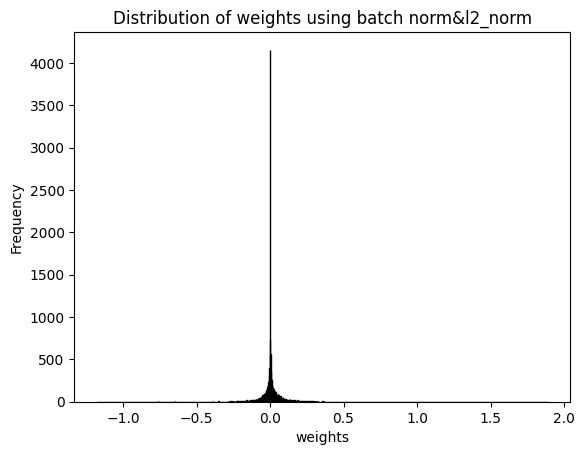

In [31]:
import matplotlib.pyplot as plt
all_weights=[]
for key,value in params.items():
  for w in value[0].flatten():
    all_weights.append(w)

plt.hist(all_weights, bins='auto', color='blue', edgecolor='black')
plt.xlabel('weights')
plt.ylabel('Frequency')
plt.title('Distribution of weights using batch norm&l2_norm')
plt.show()


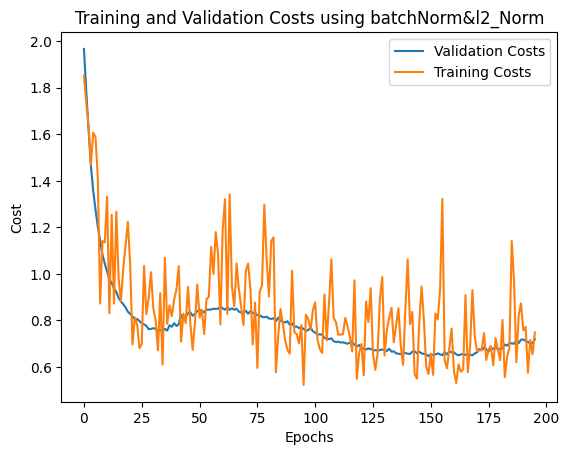

In [32]:
import matplotlib.pyplot as plt



# Plotting the training and validation costs
plt.plot(cost_valid, label='Validation Costs')
plt.plot(costs, label='Training Costs')

# Adding labels and title
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Training and Validation Costs using batchNorm&l2_Norm')

# Adding legend
plt.legend()

# Display the plot
plt.show()